In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

In [6]:
import os
import pandas as pd

project_root = r"C:\Users\harsh\YuvaIntern_Data_Science_Project"

file_path = os.path.join(
    project_root,
    "task1_air_quality",
    "../outputs",
    "air_quality_cleaned.csv"
)

print("Dataset path:")
print(file_path)

print("\nFile exists:", os.path.exists(file_path))

if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"Dataset not found at:\n{file_path}"
    )

df = pd.read_csv(file_path)

print("\nDataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset path:
C:\Users\harsh\YuvaIntern_Data_Science_Project\task1_air_quality\outputs\air_quality_cleaned.csv

File exists: True

Dataset loaded successfully!
Shape: (9357, 13)


,Datetime,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2004-03-10 20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2004-03-10 21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,2004-03-10 22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [7]:
print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (9357, 13)

Data types:
Datetime             str
CO(GT)           float64
PT08.S1(CO)      float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object

Missing values:
Datetime         0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

Duplicate rows: 0


In [8]:
features = [
    "CO(GT)",
    "PT08.S1(CO)",
    "C6H6(GT)",
    "PT08.S2(NMHC)",
    "NOx(GT)",
    "PT08.S3(NOx)",
    "NO2(GT)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH"
]

missing_features = [col for col in features if col not in df.columns]

if missing_features:
    raise ValueError(
        f"The following required features are missing: {missing_features}"
    )

cluster_data = df[features].copy()

print("Features selected for clustering:")
print(features)

print("\nClustering data shape:", cluster_data.shape)

Features selected for clustering:
['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

Clustering data shape: (9357, 12)


In [9]:
print("Missing values before final check:")
print(cluster_data.isna().sum())

if cluster_data.isna().sum().sum() > 0:
    cluster_data = cluster_data.fillna(cluster_data.median())

print("\nMissing values after treatment:")
print(cluster_data.isna().sum().sum())

Missing values before final check:
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

Missing values after treatment:
0


In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(cluster_data)

print("Original shape:", cluster_data.shape)
print("Scaled shape:", X_scaled.shape)

print("\nMean of first few scaled features:")
print(X_scaled.mean(axis=0)[:5].round(4))

print("\nStandard deviation of first few scaled features:")
print(X_scaled.std(axis=0)[:5].round(4))

Original shape: (9357, 12)
Scaled shape: (9357, 12)

Mean of first few scaled features:
[-0.  0.  0.  0.  0.]

Standard deviation of first few scaled features:
[1. 1. 1. 1. 1.]


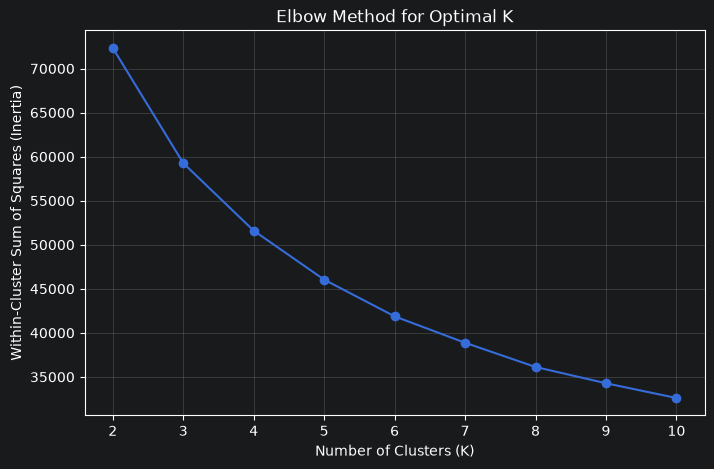

In [11]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(k_values, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("Elbow Method for Optimal K")

plt.xticks(k_values)
plt.grid(True, alpha=0.3)

plt.show()

In [12]:
silhouette_scores = {}

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score

silhouette_df = pd.DataFrame(
    list(silhouette_scores.items()),
    columns=["K", "Silhouette Score"]
)

print(silhouette_df.round(4))

    K  Silhouette Score
0   2            0.3265
1   3            0.2293
2   4            0.2257
3   5            0.2162
4   6            0.2057
5   7            0.2061
6   8            0.2029
7   9            0.1976
8  10            0.1988


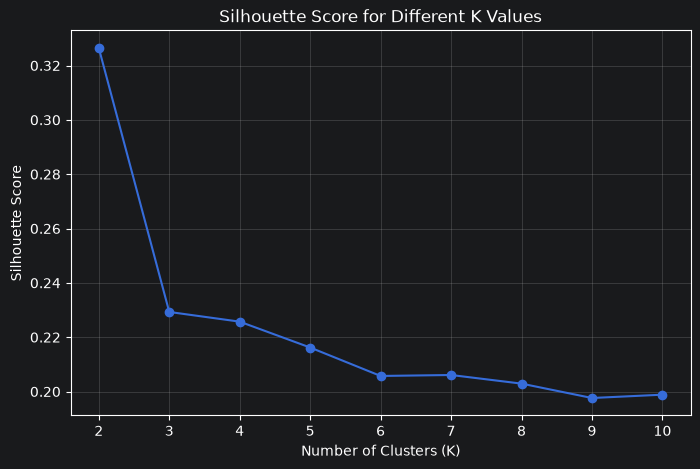

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_df["K"],
    silhouette_df["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)

plt.show()

In [14]:
optimal_k = 4

print("Selected number of clusters:", optimal_k)

Selected number of clusters: 4


In [15]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

cluster_data["Cluster"] = cluster_labels

print("K-Means clustering completed successfully.")
print("\nCluster counts:")
print(cluster_data["Cluster"].value_counts().sort_index())

K-Means clustering completed successfully.

Cluster counts:
Cluster
0    1610
1    1793
2    3253
3    2701
Name: count, dtype: int64


Cluster
0    1610
1    1793
2    3253
3    2701
Name: count, dtype: int64


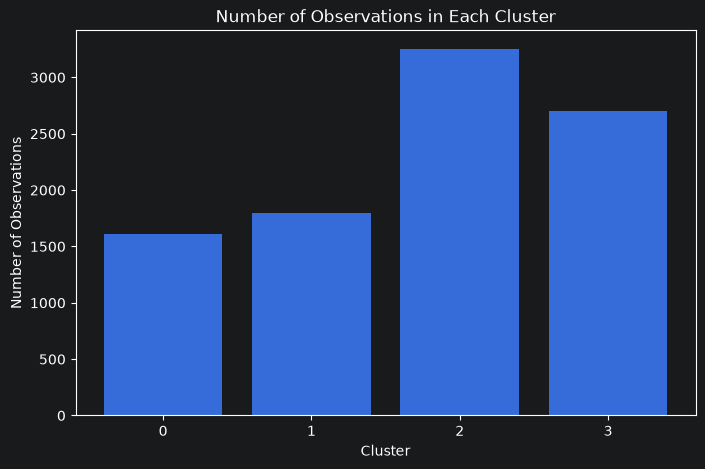

In [16]:
cluster_counts = (
    cluster_data["Cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_counts)

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Observations")
plt.title("Number of Observations in Each Cluster")

plt.show()

In [17]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = cluster_labels

print("Explained variance:")
print(
    "PC1:",
    round(pca.explained_variance_ratio_[0] * 100, 2),
    "%"
)

print(
    "PC2:",
    round(pca.explained_variance_ratio_[1] * 100, 2),
    "%"
)

print(
    "Total:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

Explained variance:
PC1: 55.1 %
PC2: 20.5 %
Total: 75.59 %


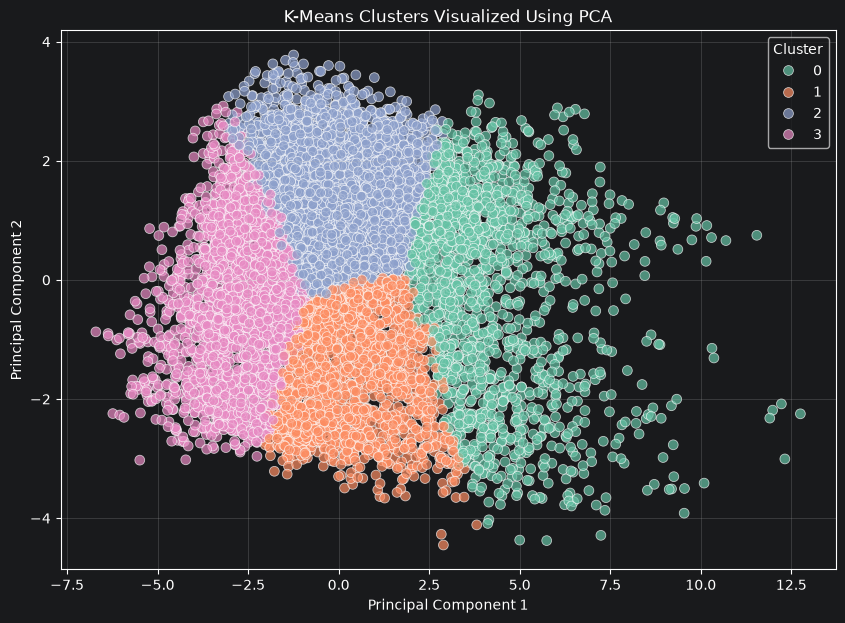

In [18]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=50,
    alpha=0.7
)

plt.title("K-Means Clusters Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")
plt.grid(True, alpha=0.3)

plt.show()

In [19]:
cluster_profiles = (
    cluster_data
    .groupby("Cluster")[features]
    .mean()
    .round(2)
)

print("Cluster Profiles:")
display(cluster_profiles)

Cluster Profiles:


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Cluster,,,,,,,,,,,,
0,4.11,1437.20,22.31,1349.98,484.67,550.90,152.98,1865.33,1626.03,18.63,52.80,1.11
1,2.30,1127.96,9.21,938.86,342.55,730.58,147.75,1243.02,1132.83,11.16,53.88,0.72
2,1.82,1082.46,9.92,964.00,149.00,799.72,98.98,1605.30,965.49,25.54,41.55,1.27
3,1.07,895.99,3.32,660.45,118.99,1113.87,80.81,1175.41,651.46,14.11,53.33,0.88


In [20]:
cluster_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

cluster_scaled_df["Cluster"] = cluster_labels

cluster_profile_scaled = (
    cluster_scaled_df
    .groupby("Cluster")[features]
    .mean()
    .round(2)
)

display(cluster_profile_scaled)

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Cluster,,,,,,,,,,,,
0,1.53,1.59,1.68,1.57,1.28,-1.13,0.92,1.20,1.55,0.04,0.21,0.22
1,0.16,0.14,-0.11,0.00,0.55,-0.41,0.80,-0.63,0.29,-0.82,0.27,-0.77
2,-0.20,-0.07,-0.01,0.10,-0.44,-0.14,-0.30,0.44,-0.14,0.84,-0.45,0.62
3,-0.77,-0.95,-0.91,-1.06,-0.60,1.11,-0.72,-0.83,-0.94,-0.48,0.24,-0.37


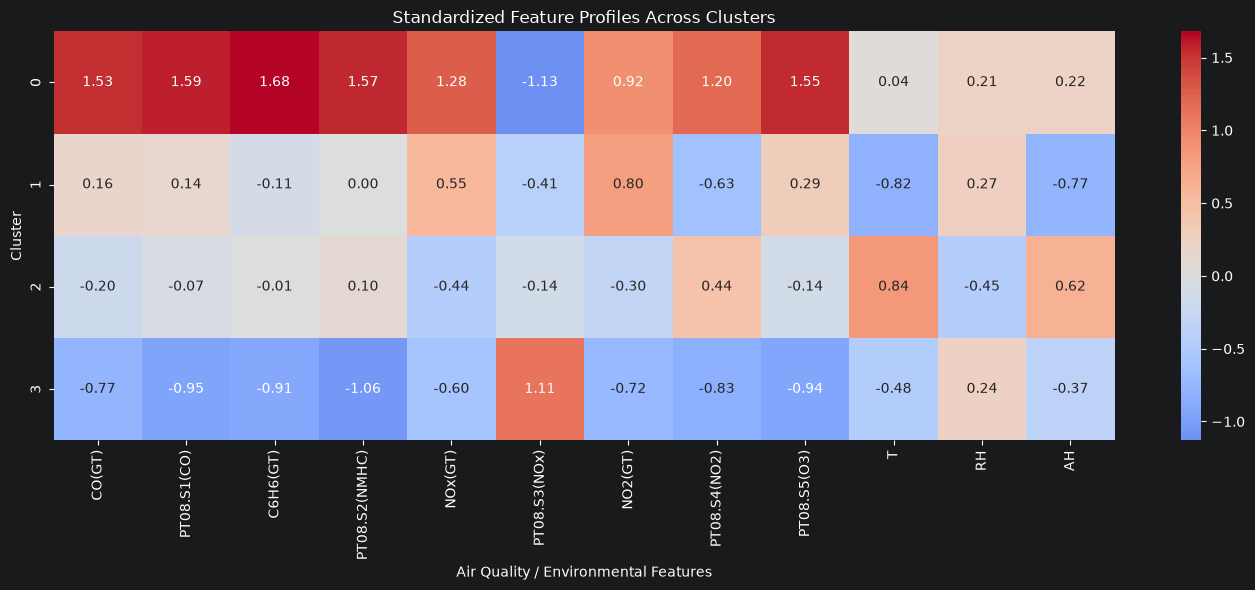

In [21]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    cluster_profile_scaled,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)

plt.title("Standardized Feature Profiles Across Clusters")
plt.xlabel("Air Quality / Environmental Features")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

         CO(GT)  NOx(GT)  NO2(GT)
Cluster                          
0          4.11   484.67   152.98
1          2.30   342.55   147.75
2          1.82   149.00    98.98
3          1.07   118.99    80.81


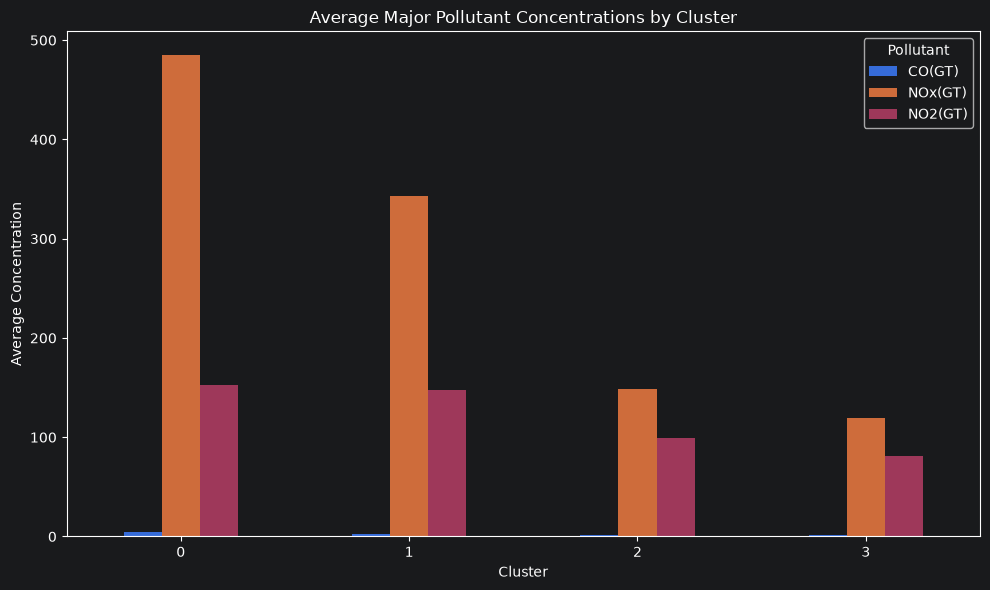

In [22]:
important_pollutants = [
    "CO(GT)",
    "NOx(GT)",
    "NO2(GT)"
]

cluster_pollutants = (
    cluster_data
    .groupby("Cluster")[important_pollutants]
    .mean()
)

print(cluster_pollutants.round(2))

cluster_pollutants.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Major Pollutant Concentrations by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Concentration")
plt.xticks(rotation=0)
plt.legend(title="Pollutant")

plt.tight_layout()
plt.show()

In [23]:
pollution_score = (
    cluster_data
    .groupby("Cluster")[important_pollutants]
    .mean()
    .mean(axis=1)
)

print("Average pollution score by cluster:")
print(pollution_score.sort_values(ascending=False).round(2))

high_pollution_cluster = pollution_score.idxmax()

print(
    "\nCluster with highest average major pollutant levels:",
    high_pollution_cluster
)

Average pollution score by cluster:
Cluster
0    213.92
1    164.20
2     83.27
3     66.96
dtype: float64

Cluster with highest average major pollutant levels: 0


In [24]:
cluster_percentage = (
    cluster_data["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

cluster_percentage = cluster_percentage.round(2)

print("Cluster distribution (%):")
print(cluster_percentage)

Cluster distribution (%):
Cluster
0    17.21
1    19.16
2    34.77
3    28.87
Name: proportion, dtype: float64


In [25]:
final_silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print("Final Clustering Evaluation")
print("-" * 35)
print("Number of clusters:", optimal_k)
print("Silhouette Score:", round(final_silhouette, 4))
print("Observations:", len(cluster_data))

Final Clustering Evaluation
-----------------------------------
Number of clusters: 4
Silhouette Score: 0.2257
Observations: 9357


In [27]:
# Project root
project_root = r"C:\Users\harsh\YuvaIntern_Data_Science_Project"

# Create Task 3 output folders
output_dir = os.path.join(project_root, "task3_clustering", "outputs")
figures_dir = os.path.join(output_dir, "figures")

os.makedirs(figures_dir, exist_ok=True)

# Save clustered dataset
df_output = df.copy()
df_output["Cluster"] = cluster_labels

output_path = os.path.join(
    output_dir,
    "air_quality_clustered.csv"
)

df_output.to_csv(output_path, index=False)

print("=" * 50)
print("TASK 3 FILES READY")
print("=" * 50)
print("Clustered dataset:")
print(output_path)
print("\nFigures folder:")
print(figures_dir)
print("\nDataset shape:", df_output.shape)
print("Clusters:", sorted(df_output["Cluster"].unique()))
print("\nSaved successfully!")

TASK 3 FILES READY
Clustered dataset:
C:\Users\harsh\YuvaIntern_Data_Science_Project\task3_clustering\outputs\air_quality_clustered.csv

Figures folder:
C:\Users\harsh\YuvaIntern_Data_Science_Project\task3_clustering\outputs\figures

Dataset shape: (9357, 14)
Clusters: [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]

Saved successfully!


In [30]:
from pathlib import Path
import matplotlib.pyplot as plt

# Task 3 figure output folder
output_dir = Path(
    r"C:\Users\harsh\YuvaIntern_Data_Science_Project\task3_clustering\outputs\figures"
)

# Create folder if it doesn't exist
output_dir.mkdir(parents=True, exist_ok=True)

# Save the CURRENT figure
figure_path = output_dir / "clustering_analysis.png"

plt.savefig(figure_path, dpi=300, bbox_inches="tight")

print("Figure saved successfully!")
print("Location:", figure_path)
print("Exists:", figure_path.exists())

plt.show()

Figure saved successfully!
Location: C:\Users\harsh\YuvaIntern_Data_Science_Project\task3_clustering\outputs\figures\clustering_analysis.png
Exists: True


<Figure size 640x480 with 0 Axes>

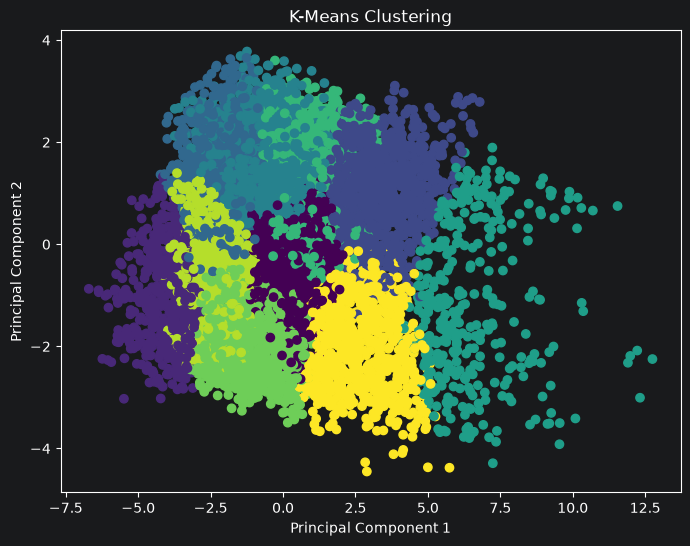

In [29]:
plt.figure(figsize=(8, 6))

# your plotting code here
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering")

plt.savefig(
    r"C:\Users\harsh\YuvaIntern_Data_Science_Project\task3_clustering\outputs\figures\kmeans_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()